In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

!pip install -q datasets

Using: cuda


In [9]:
from datasets import load_dataset
from torch.utils.data import Dataset
from torchvision import transforms

# --- Transform pipelines (unchanged) ---
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_tfms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

eval_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# --- Dataset loading via Hugging Face (replaces torchvision's broken downloader) ---
hf_train = load_dataset("uoft-cs/cifar10", split="train")
hf_test  = load_dataset("uoft-cs/cifar10", split="test")

class CIFARFromHF(Dataset):
    """Wraps a HuggingFace CIFAR-10 split so it behaves like torchvision's CIFAR10."""
    classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

    def __init__(self, hf_dataset, transform=None):
        self.ds = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        img, label = item['img'], item['label']
        if self.transform is not None:
            img = self.transform(img)
        return img, label

full_train = CIFARFromHF(hf_train, transform=train_tfms)
test_set   = CIFARFromHF(hf_test,  transform=eval_tfms)

In [10]:
val_size = 5000
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(42))

# Subtle gotcha: val_set inherits train_tfms (with augmentation). For honest validation,
# we want eval_tfms. Easiest fix: re-load the dataset with eval_tfms and index into it.
val_indices = val_set.indices
val_set = torch.utils.data.Subset(
    CIFARFromHF(hf_train, transform=eval_tfms),
    val_indices
)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=2)

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3×32×32 → 32×16×16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 32×16×16 → 64×8×8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 64×8×8 → 128×4×4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),   # ← raw logits, NO softmax here
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = SimpleCNN(num_classes=10).to(device)

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [13]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(dim=1) == y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(dim=1) == y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total

In [14]:
NUM_EPOCHS = 20
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss);     history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:2d} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

# Final test set evaluation — only the BEST checkpoint, only ONCE
model.load_state_dict(torch.load("best_model.pt"))
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test accuracy: {test_acc:.4f}")

Epoch  1 | train loss 1.5797 acc 0.4114 | val loss 1.1724 acc 0.5736
Epoch  2 | train loss 1.1718 acc 0.5783 | val loss 1.1543 acc 0.5960
Epoch  3 | train loss 0.9993 acc 0.6451 | val loss 0.8778 acc 0.6890
Epoch  4 | train loss 0.9064 acc 0.6822 | val loss 0.7798 acc 0.7234
Epoch  5 | train loss 0.8292 acc 0.7139 | val loss 0.8284 acc 0.7080
Epoch  6 | train loss 0.7756 acc 0.7353 | val loss 0.6762 acc 0.7552
Epoch  7 | train loss 0.7227 acc 0.7533 | val loss 0.6251 acc 0.7848
Epoch  8 | train loss 0.6806 acc 0.7683 | val loss 0.6693 acc 0.7732
Epoch  9 | train loss 0.6396 acc 0.7832 | val loss 0.5902 acc 0.7960
Epoch 10 | train loss 0.6101 acc 0.7943 | val loss 0.5719 acc 0.8050
Epoch 11 | train loss 0.5731 acc 0.8062 | val loss 0.5405 acc 0.8168
Epoch 12 | train loss 0.5448 acc 0.8188 | val loss 0.5115 acc 0.8272
Epoch 13 | train loss 0.5198 acc 0.8244 | val loss 0.5179 acc 0.8298
Epoch 14 | train loss 0.4965 acc 0.8330 | val loss 0.4774 acc 0.8444
Epoch 15 | train loss 0.4695 acc 0

In [15]:
CLASSES = ('airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck')

def predict_with_probs(model, image_tensor):
    """image_tensor: a single normalized image of shape (3, 32, 32)."""
    model.eval()
    with torch.no_grad():
        logits = model(image_tensor.unsqueeze(0).to(device))   # (1, 10)
        probs  = F.softmax(logits, dim=1)                       # (1, 10), sums to 1
        top_p, top_idx = probs.max(dim=1)
    return CLASSES[top_idx.item()], top_p.item(), probs.squeeze().cpu()

# Try it on a test image
img, label = test_set[0]
pred_class, confidence, full_dist = predict_with_probs(model, img)

print(f"True: {CLASSES[label]}")
print(f"Predicted: {pred_class} (confidence: {confidence:.2%})")
print("Full distribution:")
for cls, p in zip(CLASSES, full_dist):
    print(f"  {cls:12s} {p.item():.4f}")

True: cat
Predicted: cat (confidence: 93.48%)
Full distribution:
  airplane     0.0018
  automobile   0.0000
  bird         0.0040
  cat          0.9348
  deer         0.0015
  dog          0.0434
  frog         0.0141
  horse        0.0004
  ship         0.0001
  truck        0.0000


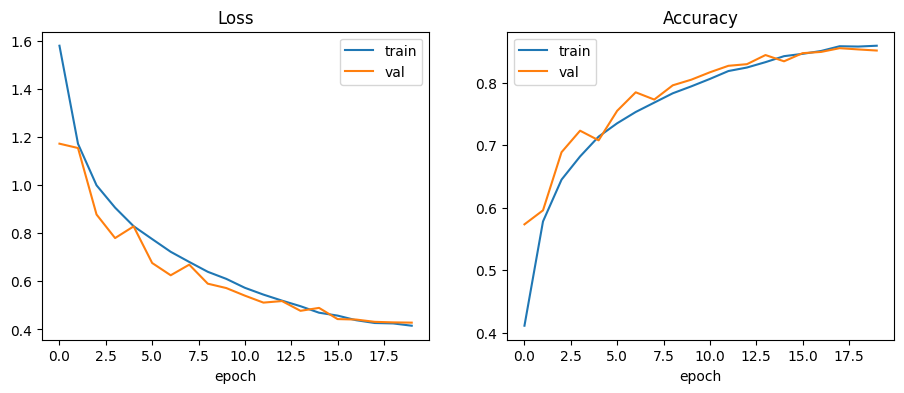

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["train_acc"],  label="train"); ax[1].plot(history["val_acc"],  label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.show()